# XGBoost Baseline — GP2 Tabular SSL Research

**Student:** Zain Qerba (160201)  
**Supervisor:** Dana El Rushaidat  
**University:** Jordan University of Science and Technology  

---

## Purpose
This notebook establishes the **XGBoost baseline** across all 3 datasets 
at 8 data fractions (100%, 50%, 10%, 8%, 6%, 4%, 2%, 1%).  
Every deep learning model in subsequent notebooks is compared against 
these numbers to identify the **crossover point** — the data fraction 
at which XGBoost stops outperforming SSL-pretrained deep models.

## Datasets
| Dataset | Task | Rows | Features |
|---|---|---|---|
| Forest Cover Type (Covertype) | Multiclass classification (7 classes) | 581,012 | 54 |
| Adult Income | Binary classification (imbalanced) | 48,842 | 14 |
| California Housing | Regression | 20,640 | 8 |

## Metrics
- **Covertype:** Accuracy + Macro-F1
- **Adult Income:** ROC-AUC + F1 + PR-AUC *(accuracy is misleading on imbalanced data)*
- **California Housing:** RMSE + MAE + R²

## Citation
Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System.
*KDD 2016*. https://doi.org/10.1145/2939672.2939785

In [1]:
# ── Cell 1: Install Dependencies ─────────────────────────────────────────────
# We install all required packages here so the notebook is self-contained
# and reproducible on any machine.
# pip skips packages that are already installed silently (--quiet flag).
# 
# Packages:
#   xgboost    — the main model we are benchmarking
#   optuna     — Bayesian hyperparameter optimization (smarter than GridSearch)
#   ucimlrepo  — official UCI downloader for the Adult Income dataset
#   scikit-learn — preprocessing, metrics, train/test split utilities
#   pandas/numpy — data handling and array operations
#   matplotlib/seaborn — plotting results and crossover curves

!pip install xgboost optuna ucimlrepo scikit-learn pandas numpy matplotlib seaborn --quiet

print(" All packages installed successfully.")

 All packages installed successfully.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ── Cell 2: Imports ───────────────────────────────────────────────────────────
# We import everything at the top so the notebook is self-contained.
# Any missing package will raise an error here — better to catch it early
# than halfway through a long experiment.

import warnings
warnings.filterwarnings('ignore')    # suppress verbose sklearn/optuna warnings

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ── Data loading ──────────────────────────────────────────────────────────────
from sklearn.datasets import fetch_covtype, fetch_california_housing
from ucimlrepo import fetch_ucirepo          # official UCI ML Repository downloader

# ── Preprocessing ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── Model ─────────────────────────────────────────────────────────────────────
import xgboost as xgb

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,   # PR-AUC — more informative than ROC-AUC on imbalanced data
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# ── Hyperparameter tuning ─────────────────────────────────────────────────────
import optuna
# Suppress Optuna's per-trial output — we only want the final result
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"XGBoost version : {xgb.__version__}")
print(f"Optuna version  : {optuna.__version__}")
print(" All imports successful.")

XGBoost version : 3.2.0
Optuna version  : 4.8.0
 All imports successful.


In [3]:
# ── Cell 3: Global Configuration ─────────────────────────────────────────────
# All experiment settings are defined here in one place.
# If we need to change anything (seed, fractions, number of trials),
# we change it here and re-run — everything stays consistent automatically.

# ── Reproducibility ───────────────────────────────────────────────────────────
# RANDOM_STATE = 42 is a fixed seed passed to every random operation.
# This ensures we get exactly the same results every time we run the notebook.
# Without this, results would differ slightly on each run.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Data Fractions ────────────────────────────────────────────────────────────
# These are the 4 training data fractions from our research design.
# 1.0 = use 100% of training data
# 0.5 = use 50% of training data
# 0.1 = use 10% of training data  
# 0.08 = use 8% of training data  
# 0.06 = use 6% of training data  
# 0.04 = use 4% of training data  
# 0.02 = use 2% of training data  
# 0.01 = use only 1% of training data
# We reduce labeled data progressively to find the crossover point —
# the fraction at which XGBoost stops outperforming SSL deep models.
FRACTIONS = [1.0, 0.5, 0.1, 0.08, 0.06, 0.04, 0.02, 0.01]

# ── Optuna Trials ─────────────────────────────────────────────────────────────
# N_OPTUNA_TRIALS = number of hyperparameter combinations Optuna will try.
N_OPTUNA_TRIALS = 50

# ── Output Path ───────────────────────────────────────────────────────────────
# All results are saved to CSV after each experiment.
# This means if the notebook crashes halfway, we don't lose earlier results.
RESULTS_DIR = os.path.join("..", "results")
os.makedirs(RESULTS_DIR, exist_ok=True)      # create folder if it doesn't exist
RESULTS_PATH = os.path.join(RESULTS_DIR, "xgboost_results.csv")

print(f"Results will be saved to : {RESULTS_PATH}")
print(f"Fractions                : {FRACTIONS}")
print(f"Optuna trials            : {N_OPTUNA_TRIALS}")
print(f"Random state             : {RANDOM_STATE}")

Results will be saved to : ..\results\xgboost_results.csv
Fractions                : [1.0, 0.5, 0.1, 0.08, 0.06, 0.04, 0.02, 0.01]
Optuna trials            : 50
Random state             : 42


In [4]:
# ── Cell 4: Helper Functions ──────────────────────────────────────────────────
# Two reusable functions used across all 3 datasets.

def save_result(row: dict):
    """
    Append one experiment result to the CSV immediately after each run.
    Saving after each experiment ensures results are not lost if the 
    notebook crashes during a long run.
    """
    df_row = pd.DataFrame([row])
    file_exists = os.path.isfile(RESULTS_PATH)
    df_row.to_csv(
        RESULTS_PATH,
        mode='a',                      # append — never overwrite previous results
        header=not file_exists,        # write headers only on first save
        index=False
    )
    print(f"Saved: dataset={row['dataset']} | fraction={row['fraction']}")


def subsample(X, y, fraction, task='classification'):
    """
    Return a fraction of (X, y) for the data scaling experiments.
    Classification: stratified sampling to preserve class proportions.
    Regression: random sampling (no discrete classes to preserve).
    """
    if fraction >= 1.0:
        return X, y

    if task == 'classification':
        # Stratified split ensures rare classes appear at every fraction
        sss = StratifiedShuffleSplit(
            n_splits=1,
            test_size=1 - fraction,
            random_state=RANDOM_STATE
        )
        keep_idx, _ = next(sss.split(X, y))
        return X[keep_idx], y[keep_idx]

    else:
        n_keep = int(len(X) * fraction)
        rng = np.random.default_rng(RANDOM_STATE)
        keep_idx = rng.choice(len(X), size=n_keep, replace=False)
        return X[keep_idx], y[keep_idx]

print("Helper functions ready: save_result() and subsample()")

Helper functions ready: save_result() and subsample()


---
# Dataset 1 — Forest Cover Type (Covertype)

**Task:** Multiclass Classification (7 classes)  
**Size:** 581,012 rows × 54 features  
**Metrics:** Accuracy + Macro-F1  
**Model assigned:** TabNet (subsequent notebook)  
**XGBoost published benchmark:** ~93–94% accuracy   

**Why Macro-F1 and not just Accuracy?**  
Covertype has 7 classes with unequal sizes. Macro-F1 computes F1 
separately for each class then averages them — treating all classes 
equally regardless of size. Accuracy alone would hide poor performance 
on minority classes.

In [5]:
# ── Cell 5: Load Covertype ────────────────────────────────────────────────────
# fetch_covtype downloads from sklearn's servers (cached after first download).
# return_X_y=True returns X and y directly as numpy arrays.

print("Loading Covertype dataset...")

X_cov, y_cov = fetch_covtype(return_X_y=True)

# Covertype labels are 1–7 but XGBoost expects 0-indexed classes.
# Subtracting 1 converts them to 0–6.
y_cov = y_cov - 1

print(f"X shape : {X_cov.shape}")        # expected (581012, 54)
print(f"y shape : {y_cov.shape}")        # expected (581012,)
print(f"Classes : {np.unique(y_cov)}")   # expected [0 1 2 3 4 5 6]
print(f"\nClass distribution:")
print(pd.Series(y_cov).value_counts().sort_index())

Loading Covertype dataset...
X shape : (581012, 54)
y shape : (581012,)
Classes : [0 1 2 3 4 5 6]

Class distribution:
0    211840
1    283301
2     35754
3      2747
4      9493
5     17367
6     20510
Name: count, dtype: int64


In [6]:
# ── Cell 6: Train/Test Split — Covertype ─────────────────────────────────────
# We split ONCE here, then apply fractions to the training set only.
# The test set stays fixed across all fractions — this ensures fair comparison.
# A model trained on 1% data is evaluated on the same test set as 100% data.

X_cov_train, X_cov_test, y_cov_train, y_cov_test = train_test_split(
    X_cov, y_cov,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_cov          # preserves class proportions in both train and test
)

print(f"Train size : {X_cov_train.shape[0]:,}")   # ~464,809
print(f"Test size  : {X_cov_test.shape[0]:,}")    # ~116,203

# StandardScaler: subtract mean, divide by standard deviation.
# XGBoost is tree-based so it doesn't strictly need scaling,
# but we apply it for consistency with the deep learning models
# that will be compared against these baselines.
# CRITICAL: fit only on training data, then apply to test.
# Fitting on test data would leak information and invalidate results.
scaler_cov = StandardScaler()
X_cov_train = scaler_cov.fit_transform(X_cov_train)  # fit + transform train
X_cov_test  = scaler_cov.transform(X_cov_test)       # transform test only

print("Scaling complete — fitted on train, applied to test.")

Train size : 464,809
Test size  : 116,203
Scaling complete — fitted on train, applied to test.


In [7]:
# ── Cell 7: Optuna Objective — Covertype ─────────────────────────────────────
# This function defines WHAT Optuna optimizes.
# Optuna calls this function N times, each time suggesting different
# hyperparameters. It learns from each result which direction to search next.
# We optimize Macro-F1 because it treats all 7 classes equally.

def covertype_objective(trial, X_tr, y_tr):
    """
    Optuna objective for Covertype multiclass classification.
    Returns Macro-F1 on a validation split — Optuna maximizes this.
    """
    params = {
        # Number of trees — more trees can improve accuracy but slow training
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 1000, step=100),
        
        # How deep each tree grows — deeper = more complex, risk of overfitting
        'max_depth'        : trial.suggest_int('max_depth', 4, 10),
        
        # Learning rate — how much each tree contributes to the final prediction
        # Small rate + many trees usually beats large rate + few trees
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        
        # Fraction of training rows used per tree — reduces overfitting
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        
        # Fraction of features used per tree — adds randomness, reduces overfitting
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        
        # Minimum samples required in a leaf — higher = more conservative model
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        
        # L1 regularization — pushes less important feature weights toward zero
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        
        # L2 regularization — shrinks all weights to reduce overfitting
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),

        # Fixed settings — same for all trials
        'objective'        : 'multi:softmax',  # multiclass classification
        'num_class'        : 7,                # 7 forest cover types
        'eval_metric'      : 'mlogloss',       # cross-entropy loss for multiclass
        'tree_method'      : 'hist',           # histogram-based — fast on large data
        'device'           : 'cuda',           # use GPU (RTX 3050) for faster training
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,               # use all CPU cores
        'verbosity'        : 0,
    }

    # Internal validation split — 80% fit, 20% evaluate this trial
    # This is separate from our main test set which is never touched here
    X_t, X_v, y_t, y_v = train_test_split(
        X_tr, y_tr,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y_tr
    )

    
    # early_stopping_rounds: stop adding trees if validation loss does not
    # improve for 50 consecutive rounds — prevents overfitting and saves time
    model = xgb.XGBClassifier(**params, early_stopping_rounds=50)
    model.fit(
        X_t, y_t,
        eval_set=[(X_v, y_v)],
        verbose=False
    )

    preds = model.predict(X_v)
    return f1_score(y_v, preds, average='macro')

print("Covertype Optuna objective defined.")

Covertype Optuna objective defined.


In [9]:
# ── Cell 8: Run Covertype Experiments — All 8 Fractions ──────────────────────
# For each fraction we:
#   1. Subsample the training data to that fraction
#   2. Run Optuna to find the best hyperparameters
#   3. Retrain with best params on the full subsampled training set
#   4. Evaluate on the fixed test set (never seen during training or tuning)
#   5. Save result to CSV immediately

print("=" * 60)
print("COVERTYPE — XGBoost across 8 data fractions")
print("=" * 60)

for frac in FRACTIONS:
    print(f"Fraction: {frac*100:.0f}%")

    # Step 1: Subsample training data
    X_tr, y_tr = subsample(X_cov_train, y_cov_train, frac, task='classification')
    print(f"  Training samples: {len(X_tr):,}")

    # Step 2: Optuna search — 50 trials for all fractions (fair comparison)
    study = optuna.create_study(
        direction='maximize',              # we want highest Macro-F1
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(
        lambda trial: covertype_objective(trial, X_tr, y_tr),
        n_trials=N_OPTUNA_TRIALS,
        show_progress_bar=True
    )

    best_params = study.best_params
    print(f"  Best Macro-F1 (validation) : {study.best_value:.4f}")

    # Step 3: Retrain on full subsampled training set with best params.
    # We use a validation split + early stopping here to match exactly
    # what Optuna validated — ensures the final model is consistent
    # with the tuning process (no n_estimators mismatch).
    final_params = {
        **best_params,
        'objective'    : 'multi:softmax',
        'num_class'    : 7,
        'eval_metric'  : 'mlogloss',
        'tree_method'  : 'hist',
        'device'       : 'cuda',
        'random_state' : RANDOM_STATE,
        'n_jobs'       : -1,
        'verbosity'    : 0,
    }

    X_tr_f, X_val_f, y_tr_f, y_val_f = train_test_split(
        X_tr, y_tr,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y_tr
    )

    final_model = xgb.XGBClassifier(**final_params, early_stopping_rounds=50)
    final_model.fit(
        X_tr_f, y_tr_f,
        eval_set=[(X_val_f, y_val_f)],
        verbose=False
    )

    # Step 4: Evaluate on fixed test set
    y_pred = final_model.predict(X_cov_test)
    acc = accuracy_score(y_cov_test, y_pred)
    f1  = f1_score(y_cov_test, y_pred, average='macro')

    print(f"  TEST → Accuracy: {acc:.4f}  |  Macro-F1: {f1:.4f}")

    # Step 5: Save result to CSV
    save_result({
        'dataset'           : 'covertype',
        'model'             : 'xgboost',
        'fraction'          : frac,
        'n_train_samples'   : len(X_tr),
        'accuracy'          : round(acc, 4),
        'macro_f1'          : round(f1, 4),
        'roc_auc'           : None,
        'pr_auc'            : None,
        'f1'                : None,
        'rmse'              : None,
        'mae'               : None,
        'r2'                : None,
        'best_optuna_params': str(best_params)
    })

print("Covertype experiments complete.")

COVERTYPE — XGBoost across 8 data fractions
Fraction: 100%
  Training samples: 464,809


  0%|          | 0/50 [00:00<?, ?it/s]

  Best Macro-F1 (validation) : 0.9410
  TEST → Accuracy: 0.9658  |  Macro-F1: 0.9389
Saved: dataset=covertype | fraction=1.0
Fraction: 50%
  Training samples: 232,404


  0%|          | 0/50 [00:00<?, ?it/s]

  Best Macro-F1 (validation) : 0.9232
  TEST → Accuracy: 0.9529  |  Macro-F1: 0.9187
Saved: dataset=covertype | fraction=0.5
Fraction: 10%
  Training samples: 46,480


...

  Best Macro-F1 (validation) : 0.7405
  TEST → Accuracy: 0.8312  |  Macro-F1: 0.7411
Saved: dataset=covertype | fraction=0.04
Fraction: 2%
  Training samples: 9,296


  0%|          | 0/50 [00:00<?, ?it/s]

  Best Macro-F1 (validation) : 0.7025
  TEST → Accuracy: 0.7971  |  Macro-F1: 0.6700
Saved: dataset=covertype | fraction=0.02
Fraction: 1%
  Training samples: 4,648


  0%|          | 0/50 [00:00<?, ?it/s]

  Best Macro-F1 (validation) : 0.7098
  TEST → Accuracy: 0.7641  |  Macro-F1: 0.6249
Saved: dataset=covertype | fraction=0.01
Covertype experiments complete.


---
# Dataset 2 — Adult Income

**Task:** Binary Classification (income >50K or ≤50K)  
**Size:** 48,842 rows × 14 features (mixed numeric + categorical)  
**Class imbalance:** ~75% ≤50K, ~25% >50K  
**Metrics:** ROC-AUC + F1 + PR-AUC  
**Model assigned:** SAINT (subsequent notebook)  
**Published benchmark:** SAINT ~85.5% accuracy | T-JEPA+MLP ROC-AUC ~0.93  

**Why NOT accuracy here?**  
A model that always predicts ≤50K gets ~75% accuracy while learning nothing.  
ROC-AUC and PR-AUC evaluate the model across all decision thresholds  
and are robust to class imbalance — they tell the real story.

In [10]:
# ── Cell 9: Load Adult Income ─────────────────────────────────────────────────
# Downloaded from UCI ML Repository using the official ucimlrepo package.
# id=2 is the Adult Income dataset (Becker & Kohavi, 1996).

print("Loading Adult Income dataset...")

adult = fetch_ucirepo(id=2)
X_adult_raw = adult.data.features
y_adult_raw = adult.data.targets

print(f"Features shape : {X_adult_raw.shape}")
print(f"Targets shape  : {y_adult_raw.shape}")
print(f"\nFeature columns:\n{list(X_adult_raw.columns)}")
print(f"\nLabel distribution:\n{y_adult_raw.value_counts()}")

Loading Adult Income dataset...
Features shape : (48842, 14)
Targets shape  : (48842, 1)

Feature columns:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

Label distribution:
income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64


In [11]:
# ── Cell 10: Preprocess Adult Income ─────────────────────────────────────────
# Adult Income has two issues we must fix before training:
# 1. Labels have trailing dots (<=50K. and >50K.) — normalize and encode
# 2. Categorical columns are strings — XGBoost needs numbers

X_adult = X_adult_raw.copy()
y_adult = y_adult_raw.copy()

# ── Fix target labels ─────────────────────────────────────────────────────────
# Strip whitespace and trailing dots so <=50K. becomes <=50K
# Then encode: <=50K → 0, >50K → 1
y_adult = y_adult.iloc[:, 0].str.strip().str.rstrip('.')
le_target = LabelEncoder()
y_adult = le_target.fit_transform(y_adult)

print(f"Label classes  : {le_target.classes_}")
print(f"Encoded as     : {le_target.transform(le_target.classes_)}")

# ── Encode categorical feature columns ────────────────────────────────────────
# For string columns: fill missing values with 'Unknown' then encode to integers
# For numeric columns: fill missing values with column median
le_feat = LabelEncoder()
for col in X_adult.columns:
    if X_adult[col].dtype == object:
        X_adult[col] = X_adult[col].fillna('Unknown')
        X_adult[col] = le_feat.fit_transform(X_adult[col])
    else:
        X_adult[col] = X_adult[col].fillna(X_adult[col].median())

X_adult = X_adult.values   # convert DataFrame to numpy array

# ── Compute scale_pos_weight ──────────────────────────────────────────────────
# XGBoost parameter to handle class imbalance.
# Set to count(negative) / count(positive) — tells XGBoost to penalize
# mistakes on the minority class (>50K) more heavily during training.
neg_count = np.sum(y_adult == 0)
pos_count = np.sum(y_adult == 1)
SCALE_POS_WEIGHT = neg_count / pos_count

print(f"\nFinal X shape  : {X_adult.shape}")
print(f"Class balance  : {neg_count} negative (≤50K) | {pos_count} positive (>50K)")
print(f"scale_pos_weight = {neg_count}/{pos_count} = {SCALE_POS_WEIGHT:.2f}")

Label classes  : ['<=50K' '>50K']
Encoded as     : [0 1]

Final X shape  : (48842, 14)
Class balance  : 37155 negative (≤50K) | 11687 positive (>50K)
scale_pos_weight = 37155/11687 = 3.18


In [12]:
# ── Cell 11: Train/Test Split — Adult Income ──────────────────────────────────
# Same approach as Covertype — split once, keep test set fixed across fractions.
# Stratified to preserve the 75/25 class imbalance in both train and test.

X_adult_train, X_adult_test, y_adult_train, y_adult_test = train_test_split(
    X_adult, y_adult,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_adult        # preserves 75/25 imbalance ratio in both sets
)

print(f"Train : {X_adult_train.shape[0]:,}  |  Test : {X_adult_test.shape[0]:,}")

# Scale features — fit on train only, apply to test
scaler_adult = StandardScaler()
X_adult_train = scaler_adult.fit_transform(X_adult_train)
X_adult_test  = scaler_adult.transform(X_adult_test)

print("Scaling complete.")

Train : 39,073  |  Test : 9,769
Scaling complete.


In [13]:
# ── Cell 12: Optuna Objective — Adult Income ──────────────────────────────────
# We optimize ROC-AUC instead of accuracy because the dataset is imbalanced.
# ROC-AUC measures how well the model separates the two classes across
# all possible decision thresholds — robust to class imbalance.

def adult_objective(trial, X_tr, y_tr):
    """
    Optuna objective for Adult Income binary classification.
    Returns ROC-AUC on a validation split — Optuna maximizes this.
    """
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 1000, step=100),
        'max_depth'        : trial.suggest_int('max_depth', 3, 9),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),

        # Binary classification settings
        'objective'        : 'binary:logistic',   # outputs probability of class 1
        'eval_metric'      : 'auc',
        # scale_pos_weight tells XGBoost to weight the minority class more heavily
        'scale_pos_weight' : SCALE_POS_WEIGHT,
        'tree_method'      : 'hist',
        'device'           : 'cuda',
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
        'verbosity'        : 0,
    }

    X_t, X_v, y_t, y_v = train_test_split(
        X_tr, y_tr,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y_tr
    )

    model = xgb.XGBClassifier(**params, early_stopping_rounds=50)
    model.fit(
        X_t, y_t,
        eval_set=[(X_v, y_v)],
        verbose=False
    )

    # predict_proba returns probabilities — [:, 1] is probability of >50K
    y_prob = model.predict_proba(X_v)[:, 1]
    return roc_auc_score(y_v, y_prob)

print("Adult Income Optuna objective defined.")

Adult Income Optuna objective defined.


In [14]:
# ── Cell 13: Run Adult Income Experiments — All 8 Fractions ──────────────────
# Same structure as Covertype but with 3 metrics:
# ROC-AUC — primary metric, robust to imbalance
# F1      — harmonic mean of precision and recall at 0.5 threshold
# PR-AUC  — area under precision-recall curve, best metric for rare positives

print("=" * 60)
print("ADULT INCOME — XGBoost across 8 data fractions")
print("=" * 60)

for frac in FRACTIONS:
    print(f"Fraction: {frac*100:.0f}%")

    # Step 1: Subsample training data
    X_tr, y_tr = subsample(X_adult_train, y_adult_train, frac, task='classification')
    print(f"  Training samples: {len(X_tr):,}")

    # Step 2: Optuna search — 50 trials for all fractions (fair comparison)
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(
        lambda trial: adult_objective(trial, X_tr, y_tr),
        n_trials=N_OPTUNA_TRIALS,
        show_progress_bar=True
    )

    best_params = study.best_params
    print(f"  Best ROC-AUC (validation) : {study.best_value:.4f}")

    # Step 3: Retrain on full subsampled training set with best params.
    # We use a validation split + early stopping here to match exactly
    # what Optuna validated — ensures the final model is consistent
    # with the tuning process (no n_estimators mismatch).
    final_params = {
        **best_params,
        'objective'        : 'binary:logistic',
        'eval_metric'      : 'auc',
        'scale_pos_weight' : SCALE_POS_WEIGHT,
        'tree_method'      : 'hist',
        'device'           : 'cuda',
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
        'verbosity'        : 0,
    }

    X_tr_f, X_val_f, y_tr_f, y_val_f = train_test_split(
        X_tr, y_tr,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y_tr
    )

    final_model = xgb.XGBClassifier(**final_params, early_stopping_rounds=50)
    final_model.fit(
        X_tr_f, y_tr_f,
        eval_set=[(X_val_f, y_val_f)],
        verbose=False
    )

    # Step 4: Evaluate on fixed test set
    # predict_proba for ROC-AUC and PR-AUC (needs probabilities)
    # predict for F1 (needs class labels)
    y_pred = final_model.predict(X_adult_test)
    y_prob = final_model.predict_proba(X_adult_test)[:, 1]

    roc_auc = roc_auc_score(y_adult_test, y_prob)
    f1      = f1_score(y_adult_test, y_pred, average='binary')
    pr_auc  = average_precision_score(y_adult_test, y_prob)

    print(f"  TEST → ROC-AUC: {roc_auc:.4f}  |  F1: {f1:.4f}  |  PR-AUC: {pr_auc:.4f}")

    # Step 5: Save result
    save_result({
        'dataset'           : 'adult_income',
        'model'             : 'xgboost',
        'fraction'          : frac,
        'n_train_samples'   : len(X_tr),
        'accuracy'          : None,
        'macro_f1'          : None,
        'roc_auc'           : round(roc_auc, 4),
        'pr_auc'            : round(pr_auc, 4),
        'f1'                : round(f1, 4),
        'rmse'              : None,
        'mae'               : None,
        'r2'                : None,
        'best_optuna_params': str(best_params)
    })

print("Adult Income experiments complete.")


ADULT INCOME — XGBoost across 8 data fractions
Fraction: 100%
  Training samples: 39,073


  0%|          | 0/50 [00:00<?, ?it/s]

  Best ROC-AUC (validation) : 0.9312
  TEST → ROC-AUC: 0.9317  |  F1: 0.7128  |  PR-AUC: 0.8363
Saved: dataset=adult_income | fraction=1.0
Fraction: 50%
  Training samples: 19,536


  0%|          | 0/50 [00:00<?, ?it/s]

  Best ROC-AUC (validation) : 0.9263
  TEST → ROC-AUC: 0.9292  |  F1: 0.7185  |  PR-AUC: 0.8290
Saved: dataset=adult_income | fraction=0.5
Fraction: 10%
  Training samples: 3,907


...

  Best ROC-AUC (validation) : 0.9254
  TEST → ROC-AUC: 0.8950  |  F1: 0.6629  |  PR-AUC: 0.7472
Saved: dataset=adult_income | fraction=0.04
Fraction: 2%
  Training samples: 781


  0%|          | 0/50 [00:00<?, ?it/s]

  Best ROC-AUC (validation) : 0.9355
  TEST → ROC-AUC: 0.8851  |  F1: 0.6369  |  PR-AUC: 0.7289
Saved: dataset=adult_income | fraction=0.02
Fraction: 1%
  Training samples: 390


  0%|          | 0/50 [00:00<?, ?it/s]

  Best ROC-AUC (validation) : 0.8492
  TEST → ROC-AUC: 0.8571  |  F1: 0.5960  |  PR-AUC: 0.6626
Saved: dataset=adult_income | fraction=0.01
Adult Income experiments complete.


---
# Dataset 3 — California Housing

**Task:** Regression (predict median house value)  
**Size:** 20,640 rows × 8 features (all numeric)  
**Metrics:** RMSE + MAE + R²  
**Models assigned:** Real-TabPFN (no SSL) + T-JEPA → Real-TabPFN (novel)  
**Published benchmarks:**  
- XGBoost tuned: RMSE ~0.38, R² ~0.88  
- T-JEPA + DCNv2: RMSE 0.420 ← our novel experiment targets beating this  
- Our GP1 baseline: RMSE 0.4337, R² 0.856 ← target to beat with proper tuning  

**Metric explanations:**  
- RMSE: penalizes large errors more — lower is better  
- MAE: average absolute error in house price units — lower is better  
- R²: 1.0 = perfect, 0 = no better than always predicting the mean — higher is better

In [15]:
# ── Cell 14: Load California Housing ─────────────────────────────────────────
# Built into sklearn — no external download needed.
# 20,640 rows of California census data from 1990.
# Target: median house value in $100,000 units.

print("Loading California Housing dataset...")

housing = fetch_california_housing()
X_cal = housing.data
y_cal = housing.target

print(f"X shape        : {X_cal.shape}")
print(f"y shape        : {y_cal.shape}")
print(f"y range        : [{y_cal.min():.2f}, {y_cal.max():.2f}]")
print(f"Feature names  : {list(housing.feature_names)}")

Loading California Housing dataset...
X shape        : (20640, 8)
y shape        : (20640,)
y range        : [0.15, 5.00]
Feature names  : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [16]:
# ── Cell 15: Train/Test Split — California Housing ────────────────────────────
# No stratify for regression — continuous targets cannot be stratified.
# Same principle as before — split once, test set fixed across all fractions.

X_cal_train, X_cal_test, y_cal_train, y_cal_test = train_test_split(
    X_cal, y_cal,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"Train : {X_cal_train.shape[0]:,}  |  Test : {X_cal_test.shape[0]:,}")

# Scale features — fit on train only, apply to test
scaler_cal = StandardScaler()
X_cal_train = scaler_cal.fit_transform(X_cal_train)
X_cal_test  = scaler_cal.transform(X_cal_test)

print("Scaling complete.")

Train : 16,512  |  Test : 4,128
Scaling complete.


In [17]:
# ── Cell 16: Optuna Objective — California Housing ────────────────────────────
# We optimize RMSE — lower is better so Optuna minimizes it.
# RMSE penalizes large prediction errors more than MAE,
# making it the standard metric for regression benchmarks.

def housing_objective(trial, X_tr, y_tr):
    """
    Optuna objective for California Housing regression.
    Returns RMSE on a validation split — Optuna minimizes this.
    """
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 1000, step=100),
        'max_depth'        : trial.suggest_int('max_depth', 3, 9),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),

        # Regression settings — different from classification
        'objective'        : 'reg:squarederror',  # minimizes mean squared error
        'eval_metric'      : 'rmse',
        'tree_method'      : 'hist',
        'device'           : 'cuda',
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
        'verbosity'        : 0,
    }

    X_t, X_v, y_t, y_v = train_test_split(
        X_tr, y_tr,
        test_size=0.2,
        random_state=RANDOM_STATE
        # no stratify for regression
    )

    # XGBRegressor for regression tasks — different from XGBClassifier
    model = xgb.XGBRegressor(**params, early_stopping_rounds=50)
    model.fit(
        X_t, y_t,
        eval_set=[(X_v, y_v)],
        verbose=False
    )

    y_pred = model.predict(X_v)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    return rmse    # Optuna minimizes this

print("California Housing Optuna objective defined.")

California Housing Optuna objective defined.


In [18]:
# ── Cell 17: Run California Housing Experiments — All 8 Fractions ─────────────
# Regression task — we report RMSE, MAE, and R².
# Target to beat: T-JEPA + DCNv2 got RMSE 0.420 on this exact dataset.
# Our tuned XGBoost should beat that — establishing a strong baseline
# for the Real-TabPFN and T-JEPA → Real-TabPFN experiments.

print("=" * 60)
print("CALIFORNIA HOUSING — XGBoost across 8 data fractions")
print("=" * 60)

for frac in FRACTIONS:
    print(f" Fraction: {frac*100:.0f}%")

    # Step 1: Subsample — regression uses random sampling
    X_tr, y_tr = subsample(X_cal_train, y_cal_train, frac, task='regression')
    print(f"  Training samples: {len(X_tr):,}")

    # Step 2: Optuna search — minimize RMSE
    study = optuna.create_study(
        direction='minimize',    # lower RMSE = better
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(
        lambda trial: housing_objective(trial, X_tr, y_tr),
        n_trials=N_OPTUNA_TRIALS,
        show_progress_bar=True
    )

    best_params = study.best_params
    print(f"  Best RMSE (validation) : {study.best_value:.4f}")

    # Step 3: Retrain on full subsampled training set with best params.
    # We use a validation split + early stopping here to match exactly
    # what Optuna validated — ensures the final model is consistent
    # with the tuning process (no n_estimators mismatch).
    final_params = {
        **best_params,
        'objective'    : 'reg:squarederror',
        'eval_metric'  : 'rmse',
        'tree_method'  : 'hist',
        'device'       : 'cuda',
        'random_state' : RANDOM_STATE,
        'n_jobs'       : -1,
        'verbosity'    : 0,
    }

    X_tr_f, X_val_f, y_tr_f, y_val_f = train_test_split(
        X_tr, y_tr,
        test_size=0.2,
        random_state=RANDOM_STATE
        # no stratify — regression target is continuous
    )

    final_model = xgb.XGBRegressor(**final_params, early_stopping_rounds=50)
    final_model.fit(
        X_tr_f, y_tr_f,
        eval_set=[(X_val_f, y_val_f)],
        verbose=False
    )

    # Step 4: Evaluate on fixed test set
    y_pred = final_model.predict(X_cal_test)

    rmse = np.sqrt(mean_squared_error(y_cal_test, y_pred))
    mae  = mean_absolute_error(y_cal_test, y_pred)
    r2   = r2_score(y_cal_test, y_pred)

    print(f"  TEST → RMSE: {rmse:.4f}  |  MAE: {mae:.4f}  |  R²: {r2:.4f}")

    # Step 5: Save result
    save_result({
        'dataset'           : 'california_housing',
        'model'             : 'xgboost',
        'fraction'          : frac,
        'n_train_samples'   : len(X_tr),
        'accuracy'          : None,
        'macro_f1'          : None,
        'roc_auc'           : None,
        'pr_auc'            : None,
        'f1'                : None,
        'rmse'              : round(rmse, 4),
        'mae'               : round(mae, 4),
        'r2'                : round(r2, 4),
        'best_optuna_params': str(best_params)
    })

print("California Housing experiments complete.")


CALIFORNIA HOUSING — XGBoost across 8 data fractions
 Fraction: 100%
  Training samples: 16,512


  0%|          | 0/50 [00:00<?, ?it/s]

  Best RMSE (validation) : 0.4566
  TEST → RMSE: 0.4424  |  MAE: 0.2877  |  R²: 0.8506
Saved: dataset=california_housing | fraction=1.0
 Fraction: 50%
  Training samples: 8,256


  0%|          | 0/50 [00:00<?, ?it/s]

  Best RMSE (validation) : 0.4812
  TEST → RMSE: 0.4643  |  MAE: 0.3055  |  R²: 0.8355
Saved: dataset=california_housing | fraction=0.5
 Fraction: 10%
  Training samples: 1,651


...

  Best RMSE (validation) : 0.6123
  TEST → RMSE: 0.6449  |  MAE: 0.4484  |  R²: 0.6826
Saved: dataset=california_housing | fraction=0.04
 Fraction: 2%
  Training samples: 330


  0%|          | 0/50 [00:00<?, ?it/s]

  Best RMSE (validation) : 0.6107
  TEST → RMSE: 0.6448  |  MAE: 0.4675  |  R²: 0.6828
Saved: dataset=california_housing | fraction=0.02
 Fraction: 1%
  Training samples: 165


  0%|          | 0/50 [00:00<?, ?it/s]

  Best RMSE (validation) : 0.6351
  TEST → RMSE: 0.7078  |  MAE: 0.5299  |  R²: 0.6177
Saved: dataset=california_housing | fraction=0.01
California Housing experiments complete.


---
# Results Summary & Crossover Visualization

The plots below show how XGBoost performance changes as training data shrinks.
These curves establish the baseline — subsequent notebooks will overlay
deep learning results to identify the crossover point.

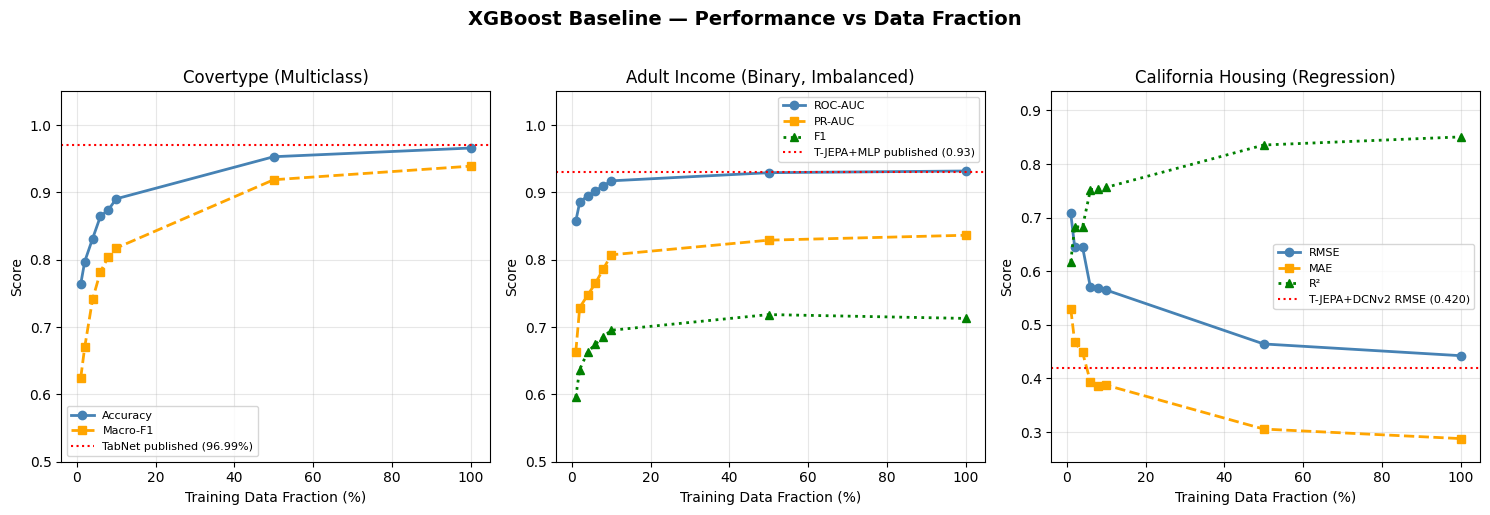

 Plot saved to results/xgboost_baseline_curves.png

FINAL RESULTS SUMMARY — XGBoost Baseline

COVERTYPE (Accuracy + Macro-F1)
----------------------------------------
     1% |   4,648 samples | Accuracy: 0.7641 | Macro-F1: 0.6249
     2% |   9,296 samples | Accuracy: 0.7971 | Macro-F1: 0.6700
     4% |  18,592 samples | Accuracy: 0.8312 | Macro-F1: 0.7411
     6% |  27,888 samples | Accuracy: 0.8645 | Macro-F1: 0.7822
     8% |  37,184 samples | Accuracy: 0.8739 | Macro-F1: 0.8040
    10% |  46,480 samples | Accuracy: 0.8904 | Macro-F1: 0.8173
    50% | 232,404 samples | Accuracy: 0.9529 | Macro-F1: 0.9187
   100% | 464,809 samples | Accuracy: 0.9658 | Macro-F1: 0.9389
  [TabNet published accuracy: 96.99%]

ADULT INCOME (ROC-AUC + F1 + PR-AUC)
----------------------------------------
     1% |    390 samples | ROC-AUC: 0.8571 | F1: 0.5960 | PR-AUC: 0.6626
     2% |    781 samples | ROC-AUC: 0.8851 | F1: 0.6369 | PR-AUC: 0.7289
     4% |  1,562 samples | ROC-AUC: 0.8950 | F1: 0.6629 | 

In [24]:
# ── Cell 18: Results Summary & Visualization ──────────────────────────────────
# Load saved results and plot performance vs data fraction for all 3 datasets.
# These plots will be reused in the final comparison notebook when we add
# deep learning results on top.

results = pd.read_csv(RESULTS_PATH)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('XGBoost Baseline — Performance vs Data Fraction', 
             fontsize=14, fontweight='bold', y=1.02)

# ── Plot 1: Covertype ─────────────────────────────────────────────────────────
cov = results[results['dataset'] == 'covertype'].sort_values('fraction')
axes[0].plot(cov['fraction'] * 100, cov['accuracy'], 
             'o-', color='steelblue', label='Accuracy', linewidth=2)
axes[0].plot(cov['fraction'] * 100, cov['macro_f1'], 
             's--', color='orange', label='Macro-F1', linewidth=2)
axes[0].axhline(y=0.9699, color='red', linestyle=':', linewidth=1.5,
                label='TabNet published (96.99%)')
axes[0].set_title('Covertype (Multiclass)')
axes[0].set_xlabel('Training Data Fraction (%)')
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0.5, 1.05)
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Adult Income ──────────────────────────────────────────────────────
adult = results[results['dataset'] == 'adult_income'].sort_values('fraction')
axes[1].plot(adult['fraction'] * 100, adult['roc_auc'], 
             'o-', color='steelblue', label='ROC-AUC', linewidth=2)
axes[1].plot(adult['fraction'] * 100, adult['pr_auc'], 
             's--', color='orange', label='PR-AUC', linewidth=2)
axes[1].plot(adult['fraction'] * 100, adult['f1'], 
             '^:', color='green', label='F1', linewidth=2)
axes[1].axhline(y=0.93, color='red', linestyle=':', linewidth=1.5,
                label='T-JEPA+MLP published (0.93)')
axes[1].set_title('Adult Income (Binary, Imbalanced)')
axes[1].set_xlabel('Training Data Fraction (%)')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8)
axes[1].set_ylim(0.5, 1.05)
axes[1].grid(True, alpha=0.3)

# ── Plot 3: California Housing ────────────────────────────────────────────────
# RMSE is lower-is-better — y-axis is auto-scaled to the actual result range
# so the performance drop across fractions is clearly visible.
cal = results[results['dataset'] == 'california_housing'].sort_values('fraction')
axes[2].plot(cal['fraction'] * 100, cal['rmse'], 
             'o-', color='steelblue', label='RMSE', linewidth=2)
axes[2].plot(cal['fraction'] * 100, cal['mae'], 
             's--', color='orange', label='MAE', linewidth=2)
axes[2].plot(cal['fraction'] * 100, cal['r2'], 
             '^:', color='green', label='R²', linewidth=2)
axes[2].axhline(y=0.420, color='red', linestyle=':', linewidth=1.5,
                label='T-JEPA+DCNv2 RMSE (0.420)')
axes[2].set_title('California Housing (Regression)')
axes[2].set_xlabel('Training Data Fraction (%)')
axes[2].set_ylabel('Score')
axes[2].set_ylim(
    cal[['rmse', 'mae', 'r2']].min().min() * 0.85,
    cal[['rmse', 'mae', 'r2']].max().max() * 1.1
)
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/xgboost_baseline_curves.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print(" Plot saved to results/xgboost_baseline_curves.png")

# ── Print clean summary table ─────────────────────────────────────────────────
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 120)

print("\n" + "=" * 60)
print("FINAL RESULTS SUMMARY — XGBoost Baseline")
print("=" * 60)

print("\nCOVERTYPE (Accuracy + Macro-F1)")
print("-" * 40)
for _, row in cov.iterrows():
    print(f"  {row['fraction']*100:>4.0f}% | {int(row['n_train_samples']):>7,} samples | Accuracy: {row['accuracy']:.4f} | Macro-F1: {row['macro_f1']:.4f}")
print("  [TabNet published accuracy: 96.99%]")

print("\nADULT INCOME (ROC-AUC + F1 + PR-AUC)")
print("-" * 40)
for _, row in adult.iterrows():
    print(f"  {row['fraction']*100:>4.0f}% | {int(row['n_train_samples']):>6,} samples | ROC-AUC: {row['roc_auc']:.4f} | F1: {row['f1']:.4f} | PR-AUC: {row['pr_auc']:.4f}")
print("  [T-JEPA+MLP published ROC-AUC: ~0.93]")

print("\nCALIFORNIA HOUSING (RMSE + MAE + R²)")
print("-" * 40)
for _, row in cal.iterrows():
    print(f"  {row['fraction']*100:>4.0f}% | {int(row['n_train_samples']):>6,} samples | RMSE: {row['rmse']:.4f} | MAE: {row['mae']:.4f} | R²: {row['r2']:.4f}")
print("  [T-JEPA+DCNv2: RMSE 0.420]")